# Notebook Objectives

This notebook loads the behavior data with the trial by trial neural values (computed by the code ```neural_value_RUN_all_sessions.py```).

Results include:
* Neural value vs. behavior (last 3 outcomes, behavioral value, long history, etc)

---
# Setup


In [1]:
from neural_value_helpers import *
from popy.config import COLORS

plt.rcParams.update({'font.size': 8})


---
# Section 1: Get data (load from file)


In [2]:
behav_new = pd.read_pickle(os.path.join(PATH, 'notebooks', 'population_decoding', 'results', 'behav_neural_value', 'behav.pkl'))
#behav_new = behav_new.loc[behav_new.subregion=='dLPFC']
# remove 5% outliers from dV
#behav_new = behav_new.loc[behav_new['V_t'].abs() < behav_new['V_t'].abs().quantile(0.95)]
behav_new

,monkey,session,subregion,trial_id,block_id,best_target,target,feedback,switch,stay_value,...,R_6,R_7,R_8,fb_sequence,V_t_-4_-2,V_t_p1_-4_-2,dV_-4_-2,V_t_2_3.5,V_t_p1_2_3.5,dV_2_3.5
0,ka,230720,MCC,8,0,2,3.0,0.0,1.0,0.283056,...,0.0,0.0,0.0,2.0,-0.150551,0.204889,0.355440,-0.091075,-0.143671,-0.052596
1,ka,230720,MCC,9,0,2,2.0,0.0,1.0,0.069825,...,1.0,0.0,0.0,1.0,0.204889,-0.059881,-0.264770,-0.143671,-0.052697,0.090974
2,ka,230720,MCC,10,0,2,3.0,1.0,1.0,0.069825,...,0.0,1.0,0.0,0.0,-0.059881,-0.200961,-0.141080,-0.052697,0.034984,0.087680
3,ka,230720,MCC,11,0,2,3.0,0.0,0.0,0.479459,...,0.0,0.0,1.0,4.0,-0.200961,-0.070287,0.130675,0.034984,-0.073381,-0.108365
4,ka,230720,MCC,12,0,2,3.0,0.0,0.0,0.283056,...,1.0,0.0,0.0,2.0,-0.070287,-0.073770,-0.003484,-0.073381,0.074128,0.147510
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66351,po,200722,dLPFC,373,8,1,1.0,1.0,0.0,0.503993,...,1.0,1.0,1.0,3.0,0.689507,0.057016,-0.632490,-0.087382,0.428223,0.515605
66352,po,200722,dLPFC,374,8,1,1.0,1.0,0.0,0.654679,...,0.0,1.0,1.0,5.0,0.057016,0.362536,0.305519,0.428223,0.242185,-0.186038
66353,po,200722,dLPFC,375,8,1,1.0,1.0,0.0,0.759587,...,0.0,0.0,1.0,6.0,0.362536,0.786138,0.423602,0.242185,0.515087,0.272902
66354,po,200722,dLPFC,376,8,1,1.0,1.0,0.0,0.832624,...,1.0,0.0,0.0,7.0,0.786138,-1.142112,-1.928250,0.515087,0.148274,-0.366814


In [3]:
# normalize dV and V_t per monkey, session, subregion
for time_interval in [(-4, -2), (2, 3.5)]:
    behav_new[f'V_t_{time_interval[0]}_{time_interval[1]}'] = behav_new.groupby(['monkey', 'session', 'subregion'])[f'V_t_{time_interval[0]}_{time_interval[1]}'].transform(lambda x: (x - x.mean()) / x.std())
    behav_new[f'V_t_p1_{time_interval[0]}_{time_interval[1]}'] = behav_new.groupby(['monkey', 'session', 'subregion'])[f'V_t_p1_{time_interval[0]}_{time_interval[1]}'].transform(lambda x: (x - x.mean()) / x.std())
    behav_new[f'dV_{time_interval[0]}_{time_interval[1]}'] = behav_new[f'V_t_p1_{time_interval[0]}_{time_interval[1]}'] - behav_new[f'V_t_{time_interval[0]}_{time_interval[1]}']

behav_new

,monkey,session,subregion,trial_id,block_id,best_target,target,feedback,switch,stay_value,...,R_6,R_7,R_8,fb_sequence,V_t_-4_-2,V_t_p1_-4_-2,dV_-4_-2,V_t_2_3.5,V_t_p1_2_3.5,dV_2_3.5
0,ka,230720,MCC,8,0,2,3.0,0.0,1.0,0.283056,...,0.0,0.0,0.0,2.0,-0.763811,0.812984,1.576796,-0.657076,-1.041484,-0.384408
1,ka,230720,MCC,9,0,2,2.0,0.0,1.0,0.069825,...,1.0,0.0,0.0,1.0,0.826380,-0.362970,-1.189350,-1.020118,-0.407838,0.612280
2,ka,230720,MCC,10,0,2,3.0,1.0,1.0,0.069825,...,0.0,1.0,0.0,0.0,-0.358167,-0.989564,-0.631397,-0.392169,0.202865,0.595034
3,ka,230720,MCC,11,0,2,3.0,0.0,0.0,0.479459,...,0.0,0.0,1.0,4.0,-0.989341,-0.409184,0.580157,0.213043,-0.551911,-0.764954
4,ka,230720,MCC,12,0,2,3.0,0.0,0.0,0.283056,...,1.0,0.0,0.0,2.0,-0.404720,-0.424657,-0.019937,-0.534947,0.475513,1.010461
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66351,po,200722,dLPFC,373,8,1,1.0,1.0,0.0,0.503993,...,1.0,1.0,1.0,3.0,1.034261,0.190688,-0.843573,-0.255577,1.043113,1.298690
66352,po,200722,dLPFC,374,8,1,1.0,1.0,0.0,0.654679,...,0.0,1.0,1.0,5.0,0.192040,0.597062,0.405023,1.045273,0.574314,-0.470959
66353,po,200722,dLPFC,375,8,1,1.0,1.0,0.0,0.759587,...,0.0,0.0,1.0,6.0,0.598868,1.160500,0.561631,0.575908,1.262004,0.686096
66354,po,200722,dLPFC,376,8,1,1.0,1.0,0.0,0.832624,...,1.0,0.0,0.0,7.0,1.162935,-1.404283,-2.567218,1.264428,0.337665,-0.926763


---
# Section 2: Analysis of the neural value representation

## History in the subspace

### Short history

Using all available CPU cores for parallel processing


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:   11.6s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:   47.1s
[Parallel(n_jobs=-1)]: Done 214 out of 214 | elapsed:   55.1s finished


Analysis complete!
Spearman correlation (rho): 0.730, p-value: 3.31e-146
Spearman correlation (rho): 0.709, p-value: 2.72e-106
Spearman correlation (rho): 0.703, p-value: 5.68e-24


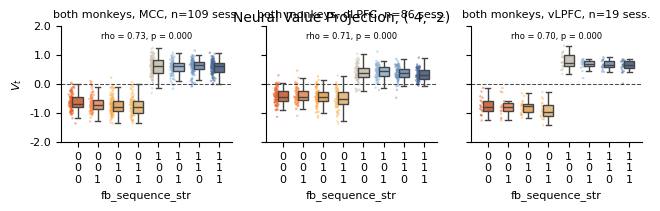

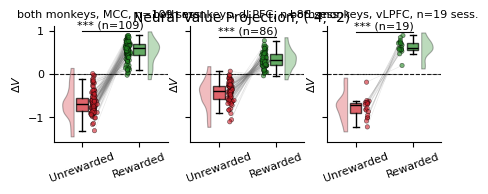

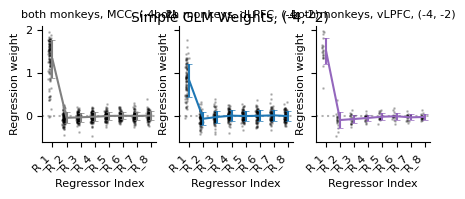

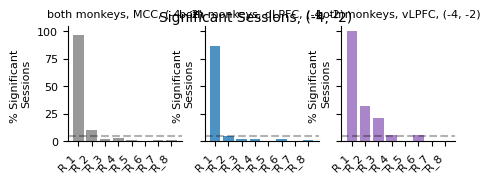

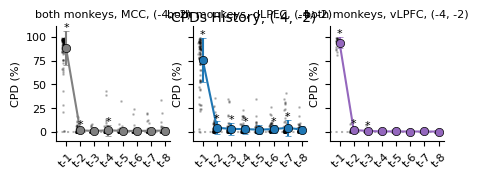

Using all available CPU cores for parallel processing


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    8.0s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:   43.6s
[Parallel(n_jobs=-1)]: Done 214 out of 214 | elapsed:   51.7s finished


Analysis complete!
Spearman correlation (rho): 0.820, p-value: 6.2e-213
Spearman correlation (rho): 0.660, p-value: 3.98e-87
Spearman correlation (rho): 0.808, p-value: 2.8e-36


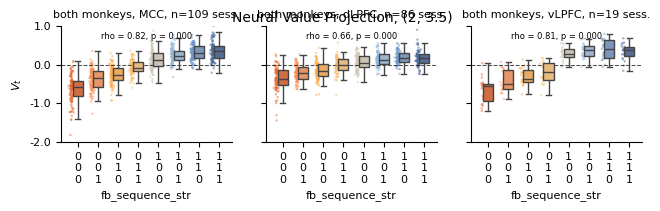

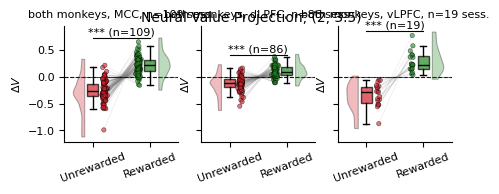

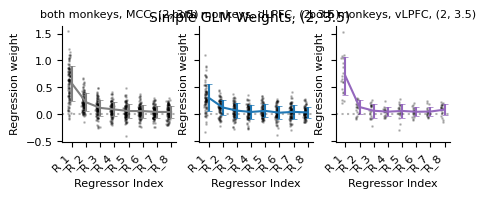

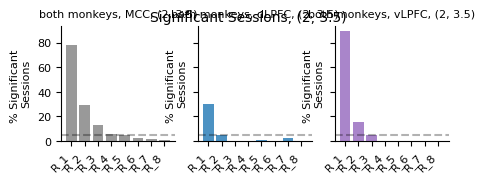

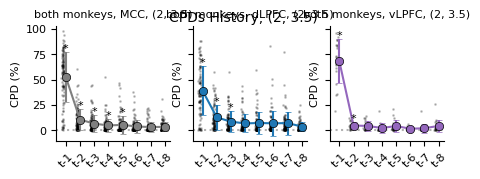

In [4]:
monkeys = 'both' # 'both', 'two'

n_perms = 999


for time_interval in [(-4, -2), (2, 3.5)]:  
    # rename columns for plotting: V_T_... to V_t, dV_... to dV
    behav_new['V_t'] = behav_new[f'V_t_{time_interval[0]}_{time_interval[1]}']
    behav_new['dV'] = behav_new[f'dV_{time_interval[0]}_{time_interval[1]}']

    # for each monkey, session, subregion, fb_sequence, take a mean of these columns
    behav_new_sess_avg_sequence = behav_new.groupby(['monkey', 'session', 'subregion', 'fb_sequence'])['V_t'].mean().reset_index()
    behav_new_sess_avg_fb = behav_new.groupby(['monkey', 'session', 'subregion', 'feedback'])['dV'].mean().reset_index()

    # calculate simple GLM weights for each session, subregion, monkey
    weights_all = simple_glm_weights(behav_new)

    # Main analysis with joblib parallelization
    cpd_all = get_cpd_all(behav_new, n_perms) 

    # Plotting
    if monkeys == 'two':
        # font = 8
        plt.rcParams.update({'font.size': 8})
        fig1, axs1 = plt.subplots(2, 3, figsize=(8, 5), sharex=True, sharey=True)
        fig2, axs2 = plt.subplots(2, 3, figsize=(5, 5), sharex=True, sharey=True)
        fig3, axs3 = plt.subplots(2, 3, figsize=(5, 5), sharex=True, sharey=True)
        fig4, axs4 = plt.subplots(2, 3, figsize=(5, 5), sharex=True, sharey=True)
        fig5, axs5 = plt.subplots(2, 3, figsize=(5, 5), sharex=True, sharey=True)

        for m, monkey in enumerate(behav_new['monkey'].unique()):
            for s, subregion in enumerate(behav_new['subregion'].unique()):
                # filter data for the current monkey and subregion
                df_temp = behav_new_sess_avg_sequence.loc[(behav_new_sess_avg_sequence['monkey'] == monkey) & (behav_new_sess_avg_sequence['subregion'] == subregion)]

                ax = axs1[m, s]
                plot_Vt_per_sequence(df_temp, paper_format=False, ylim=None, show_datapoints=True, showfliers=False, ax=ax)
                ax.set_title(f'{monkey} {subregion}, t={time_interval}', fontsize=8)

                ax = axs2[m, s]
                plot_dV_per_fb(df_temp, paper_format=False, ylim=None, show_datapoints=False, ax=ax)
                ax.set_title(f'{monkey} {subregion}, t={time_interval}', fontsize=8)

                ax = axs3[m, s]
                plot_simple_glm_weights(weights_all_temp, ax=ax)
                ax.set_title(f'{monkey}, {subregion}, {time_interval}', fontsize=8)

                ax = axs4[m, s]
                plot_prop_signif_sessions(cpd_all_temp, ax=ax)
                ax.set_title(f'{monkey}, {subregion}, {time_interval}', fontsize=8)

                ax = axs5[m, s]
                plot_cpds_history_neural_value(cpd_all_temp, null_temp, ax=ax)
                ax.set_title(f'{monkey}, {subregion}, {time_interval}', fontsize=8)


        # save figure
        #fig.savefig(f'figs/all_sess_neural_value_projection.svg', bbox_inches='tight', transparent=True)

    else:
        # font = 8
        plt.rcParams.update({'font.size': 8})
        fig1, axs1 = plt.subplots(1, 3, figsize=(7.5, 1.5), sharex=True, sharey=True)
        fig2, axs2 = plt.subplots(1, 3, figsize=(5, 1.5), sharex=True, sharey=True)
        fig3, axs3 = plt.subplots(1, 3, figsize=(5, 1.5), sharex=True, sharey=True) 
        fig4, axs4 = plt.subplots(1, 3, figsize=(5, 1.5), sharex=True, sharey=True)
        fig5, axs5 = plt.subplots(1, 3, figsize=(5, 1.5), sharex=True, sharey=True)

        monkey = 'both monkeys'

        for s, subregion in enumerate(behav_new['subregion'].unique()):
            behav_new_sess_avg_sequence_temp = behav_new_sess_avg_sequence.loc[behav_new_sess_avg_sequence['subregion'] == subregion]
            behav_new_sess_avg_fb_temp = behav_new_sess_avg_fb.loc[behav_new_sess_avg_fb['subregion'] == subregion]
            weights_all_temp = weights_all.loc[weights_all['subregion'] == subregion]
            cpd_all_temp = cpd_all.loc[cpd_all['subregion'] == subregion]
            null_temp = create_permutation_null(behav_new.loc[behav_new['subregion'] == subregion], n_perms=n_perms)

            ax = axs1[s]
            plot_Vt_per_sequence(behav_new_sess_avg_sequence_temp, paper_format=True, ylim=None, show_datapoints=True, showfliers=False, ax=ax)
            ax.set_title(f'{monkey}, {subregion}, n={len(behav_new_sess_avg_sequence_temp["session"].unique())} sess.', fontsize=8)

            ax = axs2[s]
            plot_dV_per_fb(behav_new_sess_avg_fb_temp, paper_format=True, ylim=None, show_datapoints=False, ax=ax)
            ax.set_title(f'{monkey}, {subregion}, n={len(behav_new_sess_avg_fb_temp["session"].unique())} sess.', fontsize=8)

            ax = axs3[s]
            plot_simple_glm_weights(weights_all_temp, ax=ax, show_data=False)
            ax.set_title(f'{monkey}, {subregion}, {time_interval}', fontsize=8)

            ax = axs4[s]
            plot_prop_signif_sessions(cpd_all_temp, ax=ax)
            ax.set_title(f'{monkey}, {subregion}, {time_interval}', fontsize=8)

            ax = axs5[s]
            plot_cpds_history_neural_value(cpd_all_temp, null_temp, ax=ax, show_data=False)
            ax.set_title(f'{monkey}, {subregion}, {time_interval}', fontsize=8)

        # save figure
        fig1.suptitle(f'Neural Value Projection, {time_interval}', fontsize=10)
        fig2.suptitle(f'Neural Value Projection, {time_interval}', fontsize=10)
        fig3.suptitle(f'Simple GLM Weights, {time_interval}', fontsize=10)
        fig4.suptitle(f'Significant Sessions, {time_interval}', fontsize=10)
        fig5.suptitle(f'CPDs History, {time_interval}', fontsize=10)

        fig1.savefig(f'figs/neural_value/all_sess_neural_value_projection_{time_interval}.svg', bbox_inches='tight', transparent=True)
        fig2.savefig(f'figs/neural_value/all_sess_neural_value_projection_dV_{time_interval}.svg', bbox_inches='tight', transparent=True)
        fig3.savefig(f'figs/neural_value/simple_glm_weights_{time_interval}.svg', bbox_inches='tight', transparent=True)
        fig4.savefig(f'figs/neural_value/sig_sessions_cpd_{time_interval}.svg', format='svg', bbox_inches='tight', transparent=True)
        fig5.savefig(f'figs/neural_value/cpds_history_neural_value_{time_interval}.svg', format='svg', bbox_inches='tight', transparent=True)

        plt.show()
        plt.close('all')


## Red-green plot

AttributeError: 'DataFrame' object has no attribute 'V_t_p1'

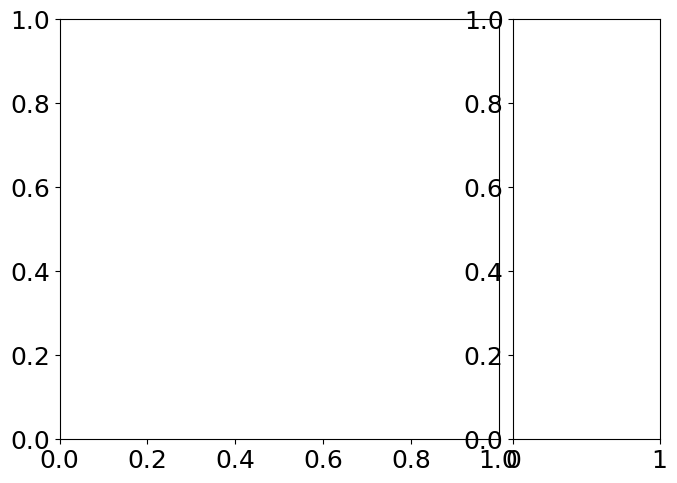

In [5]:
fig, ax = green_red_plot(behav_new, paper_format=False, xlim=None, ylim=None)
#plt.suptitle(f'{monkey} {subregion}, t_fit = {t_interest_value} s')

#fig.savefig(f'figs/green_red_plot_{monkey}_{subregion}.svg', bbox_inches='tight', transparent=True, dpi=300)

In [ ]:
get_cpd_all(behav_new, n_perms) 